--- Part 2: Data Preprocessing ---
First 5 rows:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Shape: (20640, 9)

Missing Values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Duplicates handled. Final shape: (20640, 9)


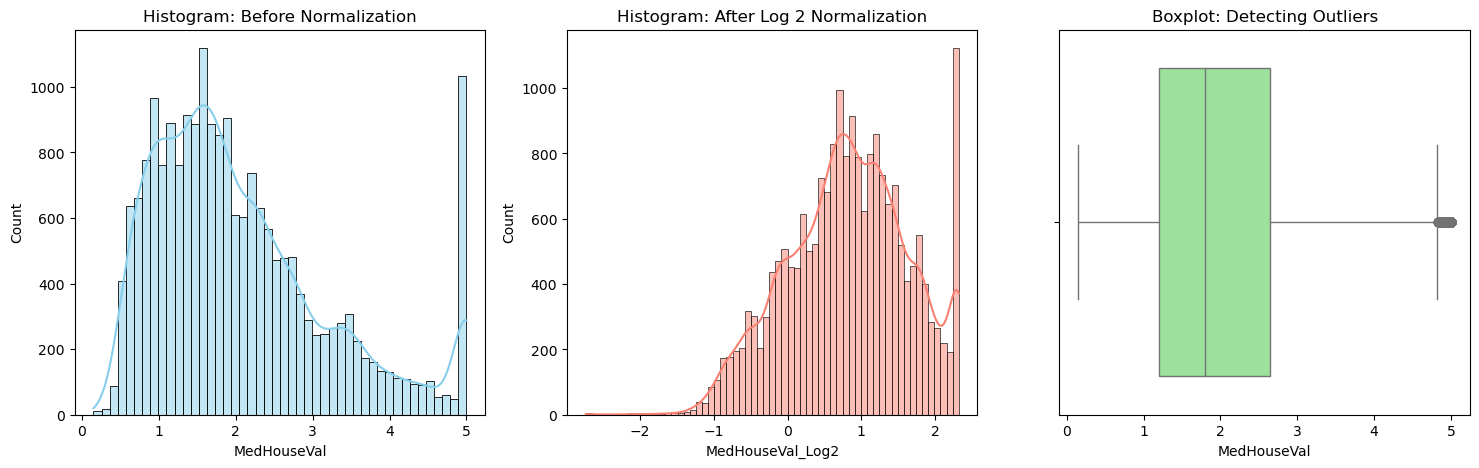

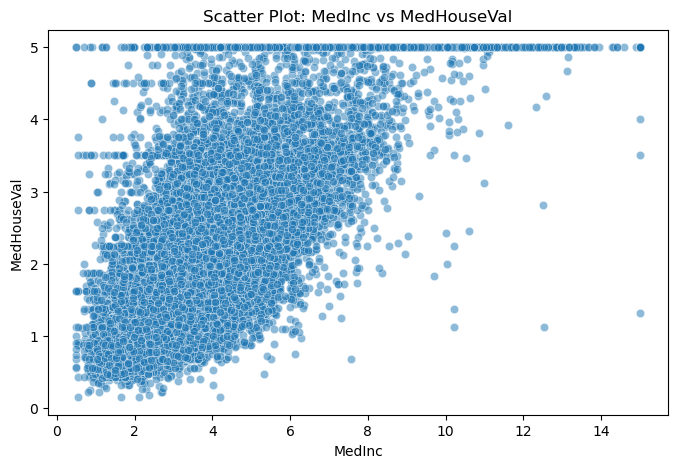


--- Part 5: Exploratory Data Analysis ---

Descriptive Statistics:
         MedInc   HouseAge  AveRooms  AveBedrms   Population   AveOccup  \
mean  3.870671  28.639486  5.429000   1.096675  1425.476744   3.070655   
50%   3.534800  29.000000  5.229129   1.048780  1166.000000   2.818116   
std   1.899822  12.585558  2.474173   0.473911  1132.462122  10.386050   

       Latitude   Longitude  MedHouseVal  MedHouseVal_Log2  
mean  35.631861 -119.569704     2.068558          0.825163  
50%   34.260000 -118.490000     1.797000          0.845591  
std    2.135952    2.003532     1.153956          0.821087  


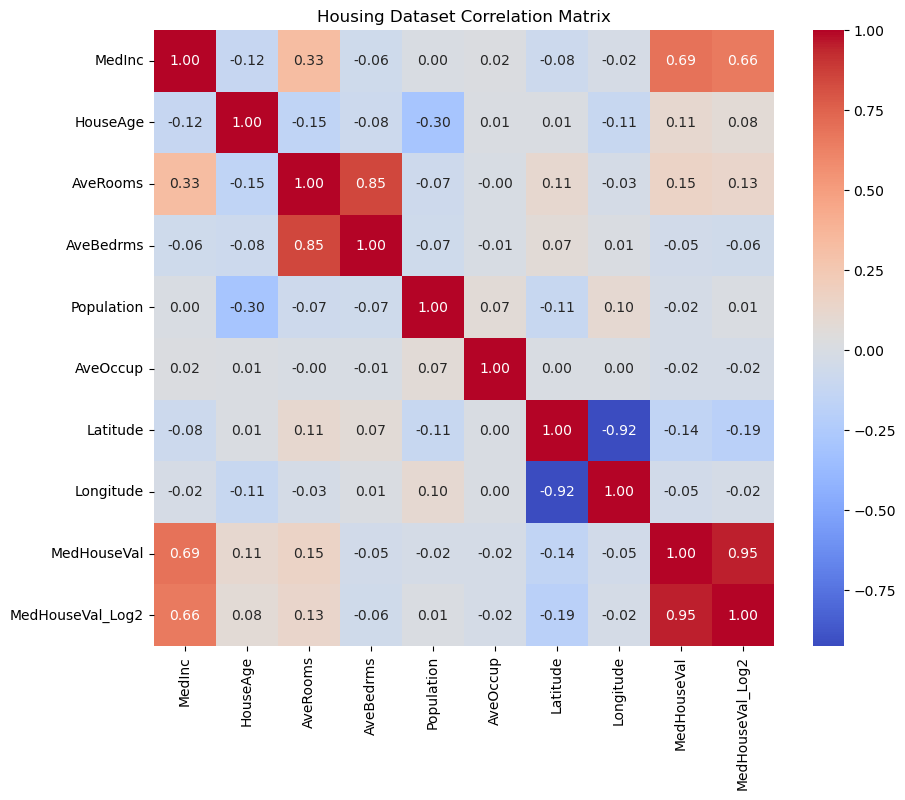


Feature that affects house price most: MedHouseVal_Log2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# --- Part 1: Data Collection ---
# Loading the dataset directly into a Pandas DataFrame 
data = fetch_california_housing(as_frame=True)
df = data.frame

# --- Part 2: Data Preprocessing ---
print("--- Part 2: Data Preprocessing ---")
# Show first 5 rows [cite: 3]
print("First 5 rows:\n", df.head())

# Check shape of dataset [cite: 3]
print("\nDataset Shape:", df.shape)

# Check for missing values [cite: 3]
print("\nMissing Values:\n", df.isnull().sum())

# Handle missing values (Filling with median) [cite: 3]
df.fillna(df.median(), inplace=True)

# Remove duplicates [cite: 3]
df.drop_duplicates(inplace=True)
print("\nDuplicates handled. Final shape:", df.shape)

# --- Part 3: Normalization ---
# Applying Log 2 Normalization to 'MedHouseVal' [cite: 3, 4]
# We add 1e-6 to prevent errors if any values are zero
df['MedHouseVal_Log2'] = np.log2(df['MedHouseVal'] + 1e-6)

# --- Part 4: Visualization ---
# Creating graphs before and after normalization 
plt.figure(figsize=(18, 5))

# 1. Histogram 
plt.subplot(1, 3, 1)
sns.histplot(df['MedHouseVal'], kde=True, color='skyblue')
plt.title('Histogram: Before Normalization')

plt.subplot(1, 3, 2)
sns.histplot(df['MedHouseVal_Log2'], kde=True, color='salmon')
plt.title('Histogram: After Log 2 Normalization')

# 2. Boxplot for Outlier Detection 
plt.subplot(1, 3, 3)
sns.boxplot(x=df['MedHouseVal'], color='lightgreen')
plt.title('Boxplot: Detecting Outliers')
plt.show()

# 3. Scatter Plot: Median Income vs House Price 
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['MedInc'], y=df['MedHouseVal'], alpha=0.5)
plt.title('Scatter Plot: MedInc vs MedHouseVal')
plt.show()

# --- Part 5: Exploratory Data Analysis (EDA) ---
print("\n--- Part 5: Exploratory Data Analysis ---")

# Mean, Median, Standard Deviation
print("\nDescriptive Statistics:\n", df.describe().loc[['mean', '50%', 'std']])

# Correlation Matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Housing Dataset Correlation Matrix')
plt.show()

# Identifying the feature that affects price the most
# (Looking for the highest correlation with MedHouseVal)

top_feature = correlation_matrix['MedHouseVal'].sort_values(ascending=False).index[1]
print(f"\nFeature that affects house price most: {top_feature}")